In [23]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df=pd. read_csv( "/content/1_boston_housing.csv" )

In [5]:
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [8]:
column_names =['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
dataset = pd.read_csv("/content/1_boston_housing.csv",
                      delimiter=r'\s+',
                      names=column_names)

In [9]:
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [11]:
df.shape

(506, 14)

In [12]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'MEDV'],
      dtype='object')

In [13]:
df.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [14]:
df.nunique()

,0
crim,504
zn,26
indus,76
chas,2
nox,81
rm,446
age,356
dis,412
rad,9
tax,66


In [15]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [16]:
df[df.isnull().any(axis=1)]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,MEDV


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [18]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [21]:
corr = df.corr()
corr.shape

(14, 14)

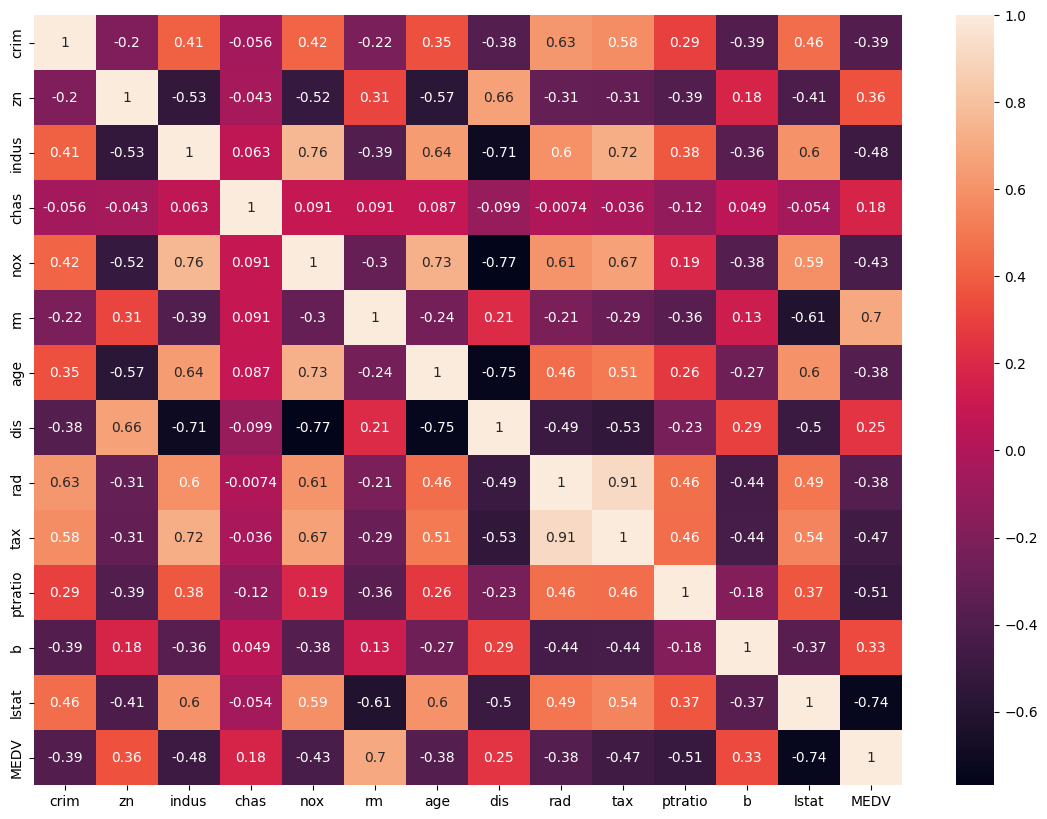

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [26]:
# Spliting target variable and independent variables
X = df.drop(['MEDV'], axis = 1)

y = df['MEDV']


In [28]:
# Splitting into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [30]:
# Import Library for Linear Regression

from sklearn.linear_model import LinearRegression

#Create a Linear egressor

lm = LinearRegression()

# Train the model using the training sets

lm.fit(X_train, y_train)


LinearRegression()

In [33]:
#value of y intercept
lm.intercept_


np.float64(31.631084035693327)

In [34]:
#Converting the coefficient values to a dataframe

coeffcients = pd.DataFrame([X_train.columns,lm.coef_]).T

coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})

coeffcients

,Attribute,Coefficients
0,crim,-0.13347
1,zn,0.035809
2,indus,0.049523
3,chas,3.119835
4,nox,-15.417061
5,rm,4.057199
6,age,-0.010821
7,dis,-1.385998
8,rad,0.242727
9,tax,-0.008702


In [37]:
# Model prediction on train data

y_pred = lm.predict(X_train)



In [38]:
# Model Evaluation

print('R^2:', metrics.r2_score(y_train, y_pred))

print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_train, y_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))

print('MAE:', metrics.mean_absolute_error(y_train, y_pred))

print('MSE:', metrics.mean_squared_error(y_train, y_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_pred)))


R^2: 0.7434997532004697
Adjusted R^2: 0.7336923908228405
MAE: 3.356826782168207
MSE: 22.545481487421423
RMSE: 4.748208239685937


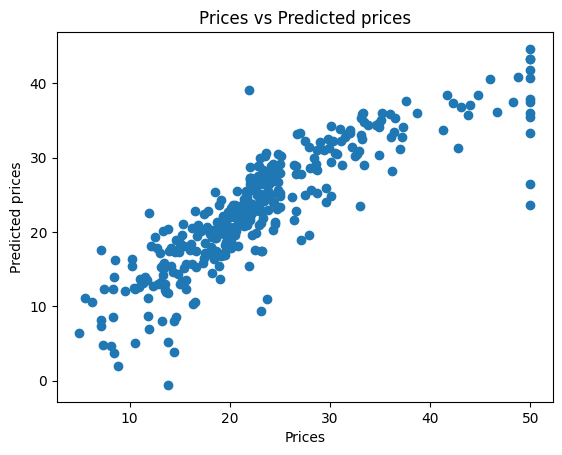

In [39]:
# Visualizing the differences between actual prices and predicted values

plt.scatter(y_train, y_pred)

plt.xlabel("Prices")

plt.ylabel("Predicted prices")

plt.title("Prices vs Predicted prices")

plt.show()

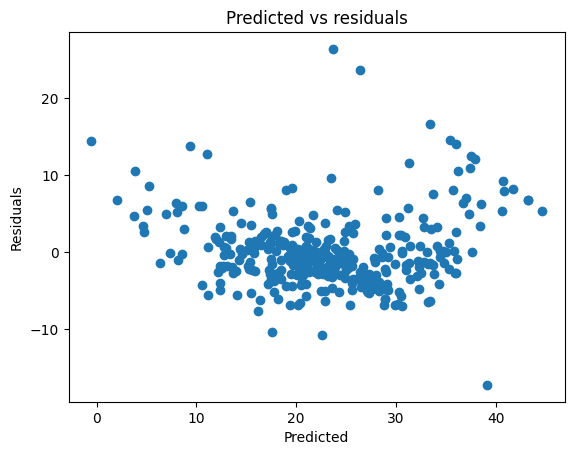

In [40]:
# Checking residuals

plt.scatter(y_pred, y_train-y_pred)

plt.title("Predicted vs residuals")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()

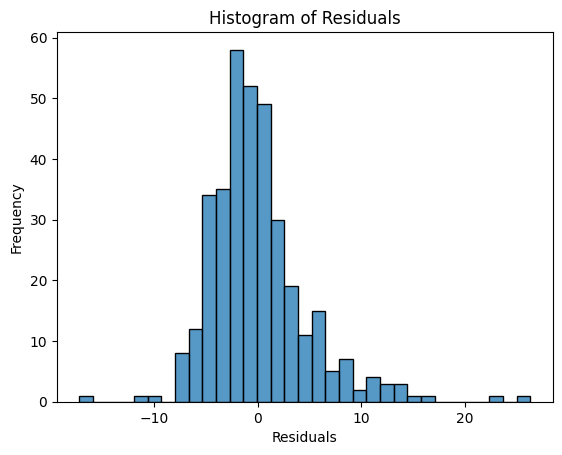

In [41]:
# Checking Normality of errors

sns.histplot(y_train-y_pred)

plt.title("Histogram of Residuals")

plt.xlabel("Residuals")

plt.ylabel("Frequency")

plt.show()

In [44]:
# Predicting Test data with the model

y_test_pred = lm.predict(X_test)



In [45]:
# Model Evaluation

acc_linreg = metrics.r2_score(y_test, y_test_pred)

print('R^2:', acc_linreg)

print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))

print('MSE:', metrics.mean_squared_error(y_test, y_test_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))


R^2: 0.7112260057484936
Adjusted R^2: 0.6840226584639314
MAE: 3.1627098714574013
MSE: 21.517444231177183
RMSE: 4.638689926172818


In [51]:
#import random forest
from sklearn.ensemble import RandomForestRegressor
#create reandom forest regressor
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

RandomForestRegressor()

In [52]:
y_pred = reg.predict(X_train)

In [53]:
# Model Evaluation

print('R^2:', metrics.r2_score(y_train, y_pred))

print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_train, y_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))

print('MAE:', metrics.mean_absolute_error(y_train, y_pred))

print('MSE:', metrics.mean_squared_error(y_train, y_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_pred)))


R^2: 0.977291989716769
Adjusted R^2: 0.9764237422647631
MAE: 0.9223333333333326
MSE: 1.9959552937853084
RMSE: 1.4127828190437866


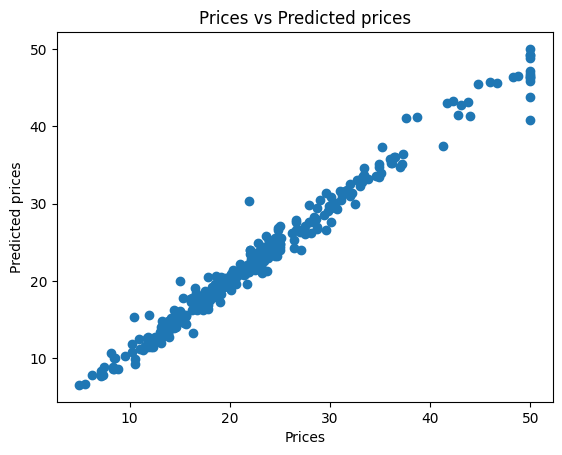

In [54]:
# Visualizing the differences between actual prices and predicted values

plt.scatter(y_train, y_pred)

plt.xlabel("Prices")

plt.ylabel("Predicted prices")

plt.title("Prices vs Predicted prices")

plt.show()

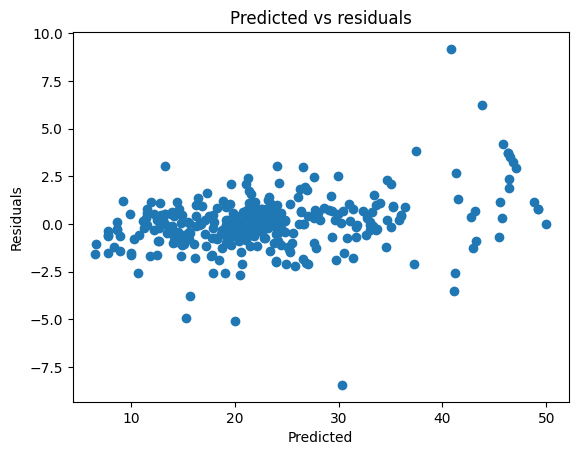

In [55]:
# Checking residuals

plt.scatter(y_pred, y_train-y_pred)

plt.title("Predicted vs residuals")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()

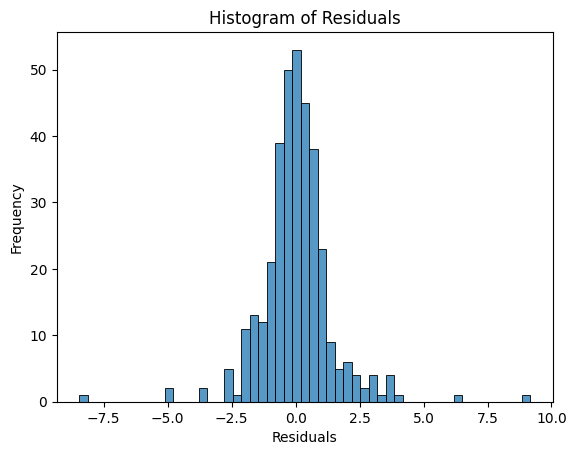

In [56]:
# Checking Normality of errors

sns.histplot(y_train-y_pred)

plt.title("Histogram of Residuals")

plt.xlabel("Residuals")

plt.ylabel("Frequency")

plt.show()

In [57]:
y_test_pred = reg.predict(X_test)

In [58]:
# Model Evaluation

acc_rf = metrics.r2_score(y_test, y_test_pred)

print('R^2:', acc_rf)

print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))

print('MSE:', metrics.mean_squared_error(y_test, y_test_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))


R^2: 0.8747711235759466
Adjusted R^2: 0.8629742004345502
MAE: 2.107881578947369
MSE: 9.331191236842104
RMSE: 3.05469986035324


In [59]:
#import XGBOOST Regressor
from xgboost import XGBRegressor
#create XGBOOST regressor
reg = XGBRegressor()
reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [60]:
y_pred = reg.predict(X_train)

In [61]:
#model Evaluation
print('R^2:', metrics.r2_score(y_train, y_pred))
print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_train, y_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
print('MAE:', metrics.mean_absolute_error(y_train, y_pred))
print('MSE:', metrics.mean_squared_error(y_train, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.9999977306758547
Adjusted R^2: 0.9999976439075786
MAE: 0.010017568243425572
MSE: 0.00019946571648799257
RMSE: 0.014123233216512165


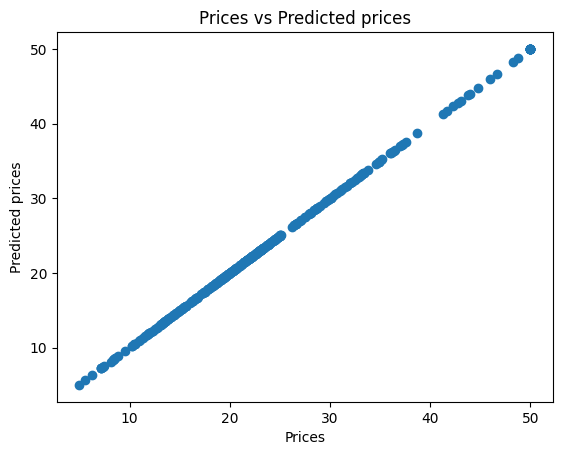

In [62]:
plt.scatter(y_train, y_pred)

plt.xlabel("Prices")

plt.ylabel("Predicted prices")

plt.title("Prices vs Predicted prices")

plt.show()

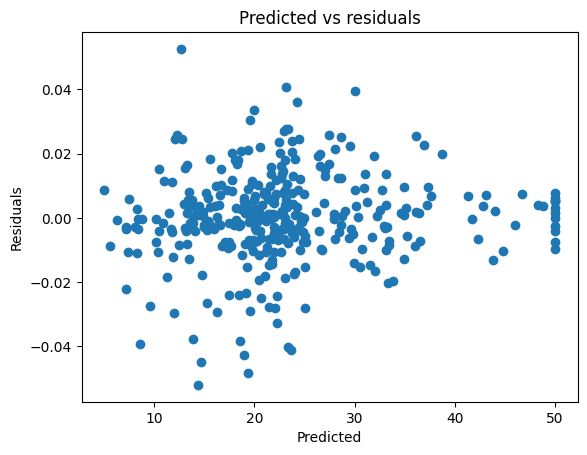

In [63]:
plt.scatter(y_pred, y_train-y_pred)

plt.title("Predicted vs residuals")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()

In [64]:
y_test_prad = reg.predict(X_test)

In [66]:
acc_xgb = metrics.r2_score(y_test, y_test_prad)
print('R^2:', acc_xgb)
print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))

print('MSE:', metrics.mean_squared_error(y_test, y_test_pred))

print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

R^2: 0.8729544676981909
Adjusted R^2: 0.8629742004345502
MAE: 2.107881578947369
MSE: 9.331191236842104
RMSE: 3.05469986035324


In [67]:
#creating scaled set to be used in model to improve our results
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [68]:
#import SVM Regressor
from sklearn.svm import SVR
#create SVM regressor
reg = SVR()
reg.fit(X_train, y_train)

SVR()

In [70]:
y_pred = reg.predict(X_train)

In [71]:
print('R^2:', metrics.r2_score(y_train, y_pred))
print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_train, y_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1))
print('MAE:', metrics.mean_absolute_error(y_train, y_pred))
print('MSE:', metrics.mean_squared_error(y_train, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.6588538556440677
Adjusted R^2: 0.6458100324775173
MAE: 3.1195796849245734
MSE: 29.985562111731866
RMSE: 5.475907423590346


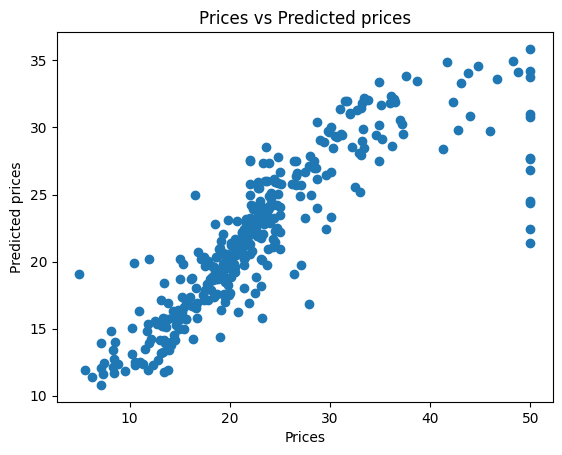

In [72]:
plt.scatter(y_train, y_pred)

plt.xlabel("Prices")

plt.ylabel("Predicted prices")

plt.title("Prices vs Predicted prices")

plt.show()

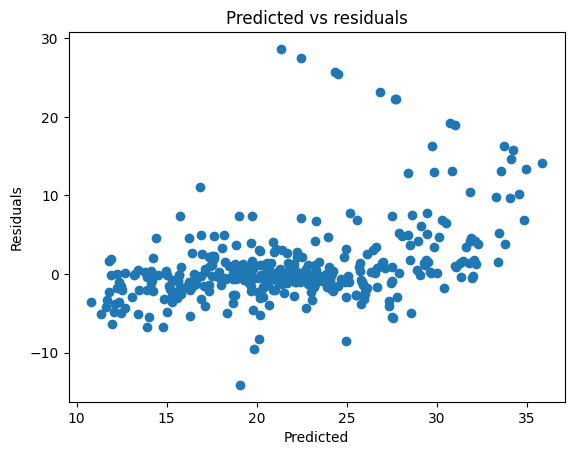

In [73]:
plt.scatter(y_pred, y_train-y_pred)

plt.title("Predicted vs residuals")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()


In [74]:
y_test_prad = reg.predict(X_test)

In [75]:
acc_svm = metrics.r2_score(y_test, y_test_prad)
print('R^2:', acc_svm)
print('Adjusted R^2:', 1 - (1 - metrics.r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_test_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

R^2: 0.6516429887336646
Adjusted R^2: 0.8629742004345502
MAE: 2.107881578947369
MSE: 9.331191236842104
RMSE: 3.05469986035324


In [76]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Support Vector'],
    'R-squared Score': [acc_linreg*100, acc_rf*100, acc_xgb*100, acc_svm*100]
})

models = models.sort_values(by='R-squared Score', ascending=False)

print(models)


               Model  R-squared Score
1      Random Forest        87.477112
2            XGBoost        87.295447
0  Linear Regression        71.122601
3     Support Vector        65.164299
